# Feature Correlations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from pathlib import Path

current = Path.cwd()
while current.name != "credit_fraud_ml":
    current = current.parent
os.chdir(current)
sys.path.append(str(current))

from src.data.data_loader import DataLoader

loader = DataLoader()
data = loader.load_all('train')
transactions = data['transactions']
customers    = data['customers']
terminals    = data['terminals']

# Build a fully merged, feature-enriched dataframe
df = transactions.merge(customers, on='CUSTOMER_ID', how='left')
df = df.merge(terminals, on='TERMINAL_ID', how='left')

# Time features
df['TX_HOUR'] = df['TX_DATETIME'].dt.hour
df['TX_DAY']  = df['TX_DATETIME'].dt.dayofweek
df['TX_WEEK'] = df['TX_DATETIME'].dt.isocalendar().week.astype(int)

# Behavioural features
df['amount_vs_mean'] = df['TX_AMOUNT'] - df['mean_amount']
df['amount_ratio']   = df['TX_AMOUNT'] / (df['mean_amount'] + 1)
df['distance']       = np.sqrt(
    (df['x_customer_id'] - df['x_terminal_id'])**2 +
    (df['y_customer_id'] - df['y_terminal_id'])**2
)

print(f"Feature matrix shape: {df.shape}")
print(f"Numeric columns: {df.select_dtypes(include=np.number).shape[1]}")

✓ Loaded 291,231 train transactions
✓ Loaded 1,000 customers
✓ Loaded 2,000 terminals
Feature matrix shape: (291231, 21)
Numeric columns: 19


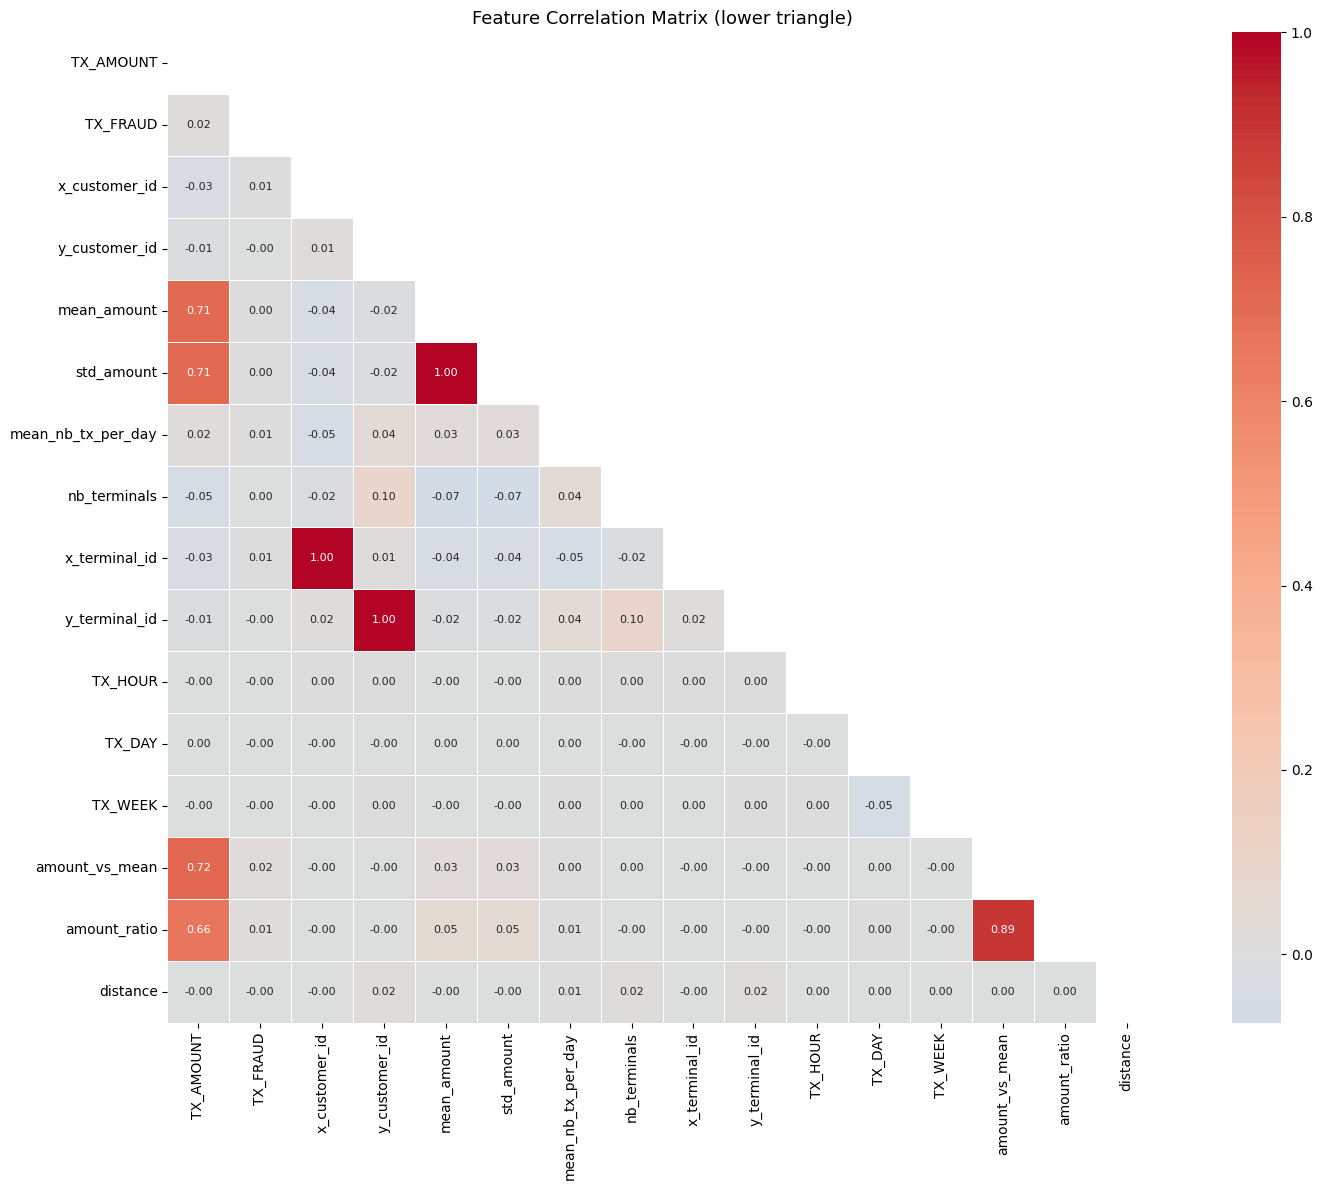

In [2]:
# ── 1. Full Correlation Heatmap ─────────────────────────────────────────────
drop_cols = ['TRANSACTION_ID', 'CUSTOMER_ID', 'TERMINAL_ID']
corr = df.drop(columns=drop_cols, errors='ignore').corr(numeric_only=True)

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.4, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix (lower triangle)', fontsize=13)
plt.tight_layout()
plt.show()

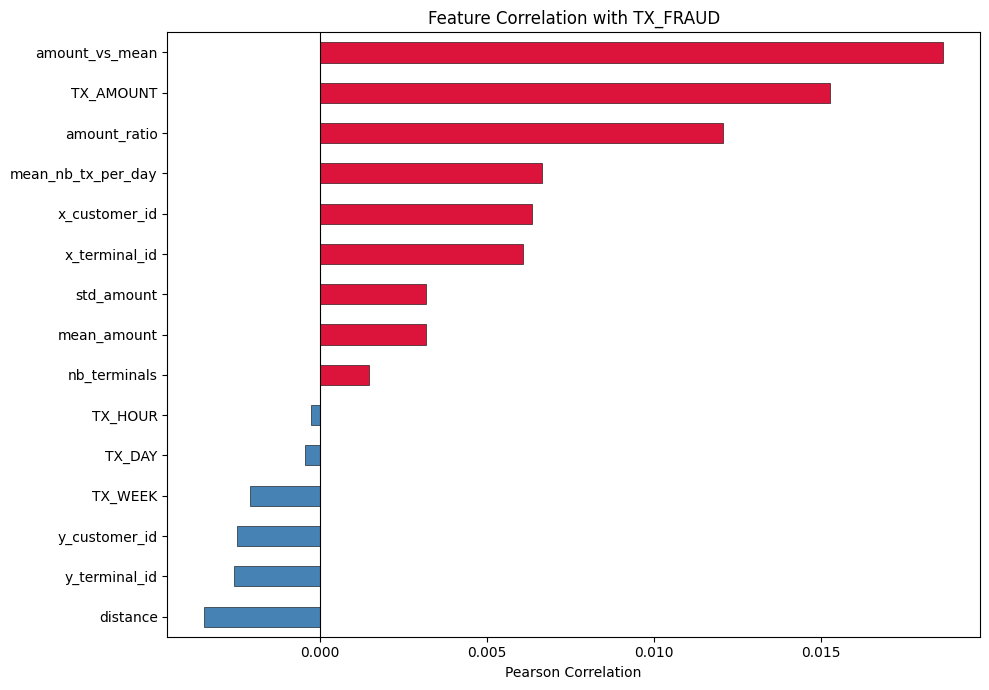

amount_vs_mean        0.018647
TX_AMOUNT             0.015275
amount_ratio          0.012067
mean_nb_tx_per_day    0.006630
x_customer_id         0.006337
x_terminal_id         0.006078
std_amount            0.003186
mean_amount           0.003186
nb_terminals          0.001468
TX_HOUR              -0.000273
TX_DAY               -0.000434
TX_WEEK              -0.002107
y_customer_id        -0.002476
y_terminal_id        -0.002576
distance             -0.003463


In [3]:
# ── 2. Correlation with TX_FRAUD (ranked bar chart) ─────────────────────────
fraud_corr = corr['TX_FRAUD'].drop('TX_FRAUD').sort_values()

colors = ['crimson' if v > 0 else 'steelblue' for v in fraud_corr]

plt.figure(figsize=(10, 7))
fraud_corr.plot(kind='barh', color=colors, edgecolor='black', linewidth=0.4)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with TX_FRAUD')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print(fraud_corr.sort_values(ascending=False).to_string())

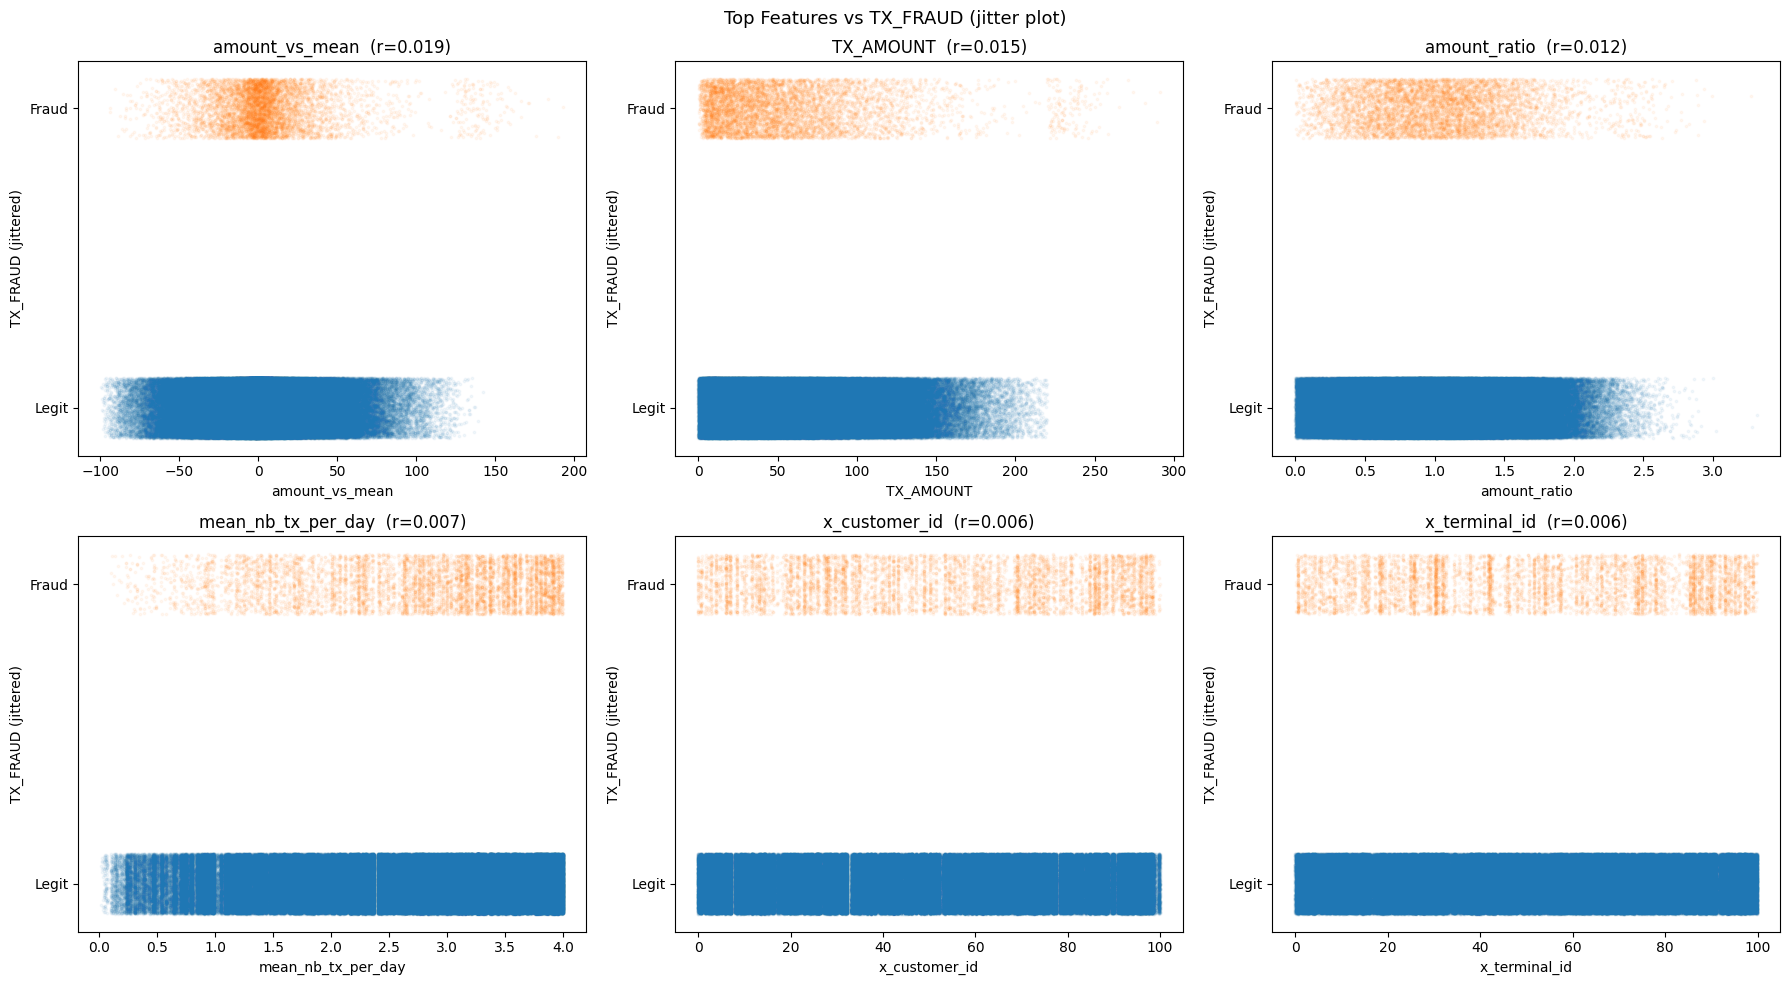

In [4]:
# ── 3. Top Feature Pair Scatter Plots (vs TX_FRAUD) ─────────────────────────
top_features = fraud_corr.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feat in zip(axes.flatten(), top_features):
    for label, grp in df.groupby('TX_FRAUD'):
        ax.scatter(grp[feat], grp['TX_FRAUD'] + np.random.uniform(-0.1, 0.1, len(grp)),
                   alpha=0.05, s=3, label='Fraud' if label else 'Legit')
    ax.set_xlabel(feat)
    ax.set_ylabel('TX_FRAUD (jittered)')
    ax.set_title(f'{feat}  (r={corr["TX_FRAUD"][feat]:.3f})')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Legit', 'Fraud'])

plt.suptitle('Top Features vs TX_FRAUD (jitter plot)', fontsize=13)
plt.tight_layout()
plt.show()

Feature pairs with |correlation| > 0.3:
     Feature A      Feature B  Correlation
    std_amount    mean_amount     1.000000
 x_terminal_id  x_customer_id     0.996305
 y_terminal_id  y_customer_id     0.996128
  amount_ratio amount_vs_mean     0.892699
amount_vs_mean      TX_AMOUNT     0.719952
    std_amount      TX_AMOUNT     0.713903
   mean_amount      TX_AMOUNT     0.713903
  amount_ratio      TX_AMOUNT     0.661603


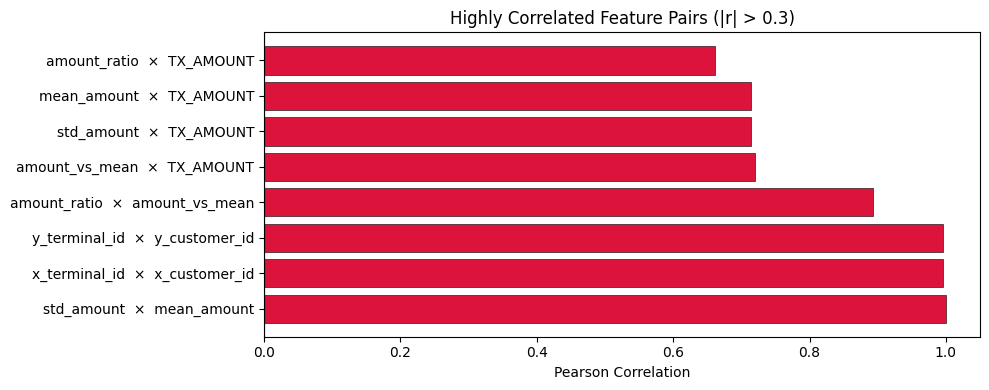

In [5]:
# ── 4. Inter-Feature Correlation: Highly Correlated Pairs ───────────────────
# Find pairs with |r| > 0.5, excluding self-correlations
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Feature A', 'Feature B', 'Correlation']
corr_pairs['abs_corr'] = corr_pairs['Correlation'].abs()
high_corr = corr_pairs[corr_pairs['abs_corr'] > 0.3].sort_values('abs_corr', ascending=False)

print("Feature pairs with |correlation| > 0.3:")
print(high_corr[['Feature A', 'Feature B', 'Correlation']].to_string(index=False))

plt.figure(figsize=(10, max(4, len(high_corr) * 0.4)))
colors = ['crimson' if v > 0 else 'steelblue' for v in high_corr['Correlation']]
plt.barh(
    high_corr['Feature A'] + '  ×  ' + high_corr['Feature B'],
    high_corr['Correlation'], color=colors, edgecolor='black', linewidth=0.4
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Highly Correlated Feature Pairs (|r| > 0.3)')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

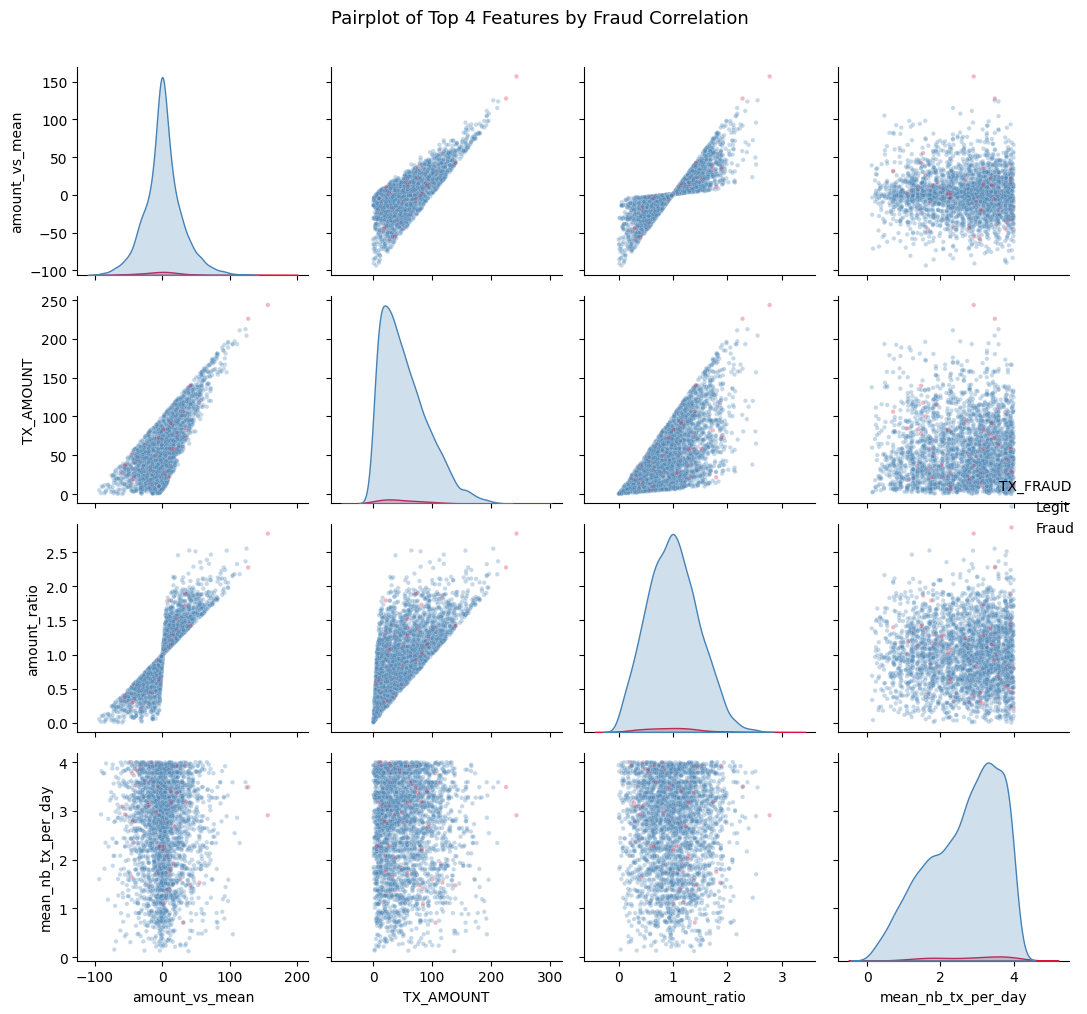

In [6]:
# ── 5. Pairplot of Top Features Coloured by Fraud ───────────────────────────
top4 = fraud_corr.abs().sort_values(ascending=False).head(4).index.tolist()
sample = df[top4 + ['TX_FRAUD']].sample(n=3000, random_state=42)
sample['TX_FRAUD'] = sample['TX_FRAUD'].map({0: 'Legit', 1: 'Fraud'})

g = sns.pairplot(sample, hue='TX_FRAUD', palette={'Legit': 'steelblue', 'Fraud': 'crimson'},
                 plot_kws={'alpha': 0.3, 's': 10}, diag_kind='kde')
g.figure.suptitle('Pairplot of Top 4 Features by Fraud Correlation', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()